In [13]:
# STEP 1 — IMPORT LIBRARIES

import pandas as pd
import numpy as np

# Data splitting
from sklearn.model_selection import train_test_split

# TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

# KNN Model
from sklearn.neighbors import KNeighborsClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [14]:
# STEP 2 — MOUNT GOOGLE DRIVE

from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')


# LOAD PREPROCESSED DATASET

file_path = '/content/drive/MyDrive/processed_fake_news_dataset.csv'

# Read dataset
df = pd.read_csv(file_path)
print("Dataset Loaded Successfully!")



print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nFirst 5 Rows:")
display(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Loaded Successfully!

Dataset Shape:
(44685, 6)

Columns:
Index(['title', 'text', 'subject', 'label', 'content', 'processed_text'], dtype='object')

First 5 Rows:


,title,text,subject,label,content,processed_text
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,0,Ben Stein Calls Out 9th Circuit Court: Committ...,ben stein call circuit court committed coup ét...
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,1,Trump drops Steve Bannon from National Securit...,trump drop steve bannon national security coun...
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,1,Puerto Rico expects U.S. to lift Jones Act shi...,puerto rico expects u lift jones act shipping ...
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,0,OOPS: Trump Just Accidentally Confirmed He Le...,oops trump accidentally confirmed leaked israe...
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,1,Donald Trump heads for Scotland to reopen a go...,donald trump head scotland reopen golf resort ...


In [15]:
# STEP 3 — CREATE FEATURES AND LABELS

# Features (Input)
# We use processed textual data
# generated after NLP preprocessing

X = df["processed_text"]


# Labels (Target Output)
# 0 → Fake News
# 1 → Real News

y = df["label"]
print("Features and Labels Created Successfully!")




print("\nNumber of Articles:")
print(len(X))

print("\nLabel Distribution:")
print(y.value_counts())

Features and Labels Created Successfully!

Number of Articles:
44685

Label Distribution:
label
0    23477
1    21208
Name: count, dtype: int64


In [16]:
# STEP 4 — TF-IDF VECTORIZATION

# Create TF-IDF Vectorizer
#
# Purpose:
# Convert textual news data into
# numerical feature vectors.

tfidf = TfidfVectorizer(

    # Keep top 5000 important words
    max_features=5000,

    # Ignore extremely common words
    max_df=0.7,

    # Ignore very rare words
    min_df=2
)


# APPLY TF-IDF TRANSFORMATION
X_tfidf = tfidf.fit_transform(X)
print("TF-IDF Vectorization Completed!")



print("\nShape of TF-IDF Matrix:")
print(X_tfidf.shape)

TF-IDF Vectorization Completed!

Shape of TF-IDF Matrix:
(44685, 5000)


In [17]:
# STEP 5 — TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(

    X_tfidf,
    y,

    # 20% testing data
    test_size=0.2,

    # Reproducibility
    random_state=42,

    # Maintain label balance
    stratify=y
)
print("Train-Test Split Completed!")



print("\nTraining Feature Shape:")
print(X_train.shape)

print("\nTesting Feature Shape:")
print(X_test.shape)

print("\nTraining Labels Shape:")
print(y_train.shape)

print("\nTesting Labels Shape:")
print(y_test.shape)

Train-Test Split Completed!

Training Feature Shape:
(35748, 5000)

Testing Feature Shape:
(8937, 5000)

Training Labels Shape:
(35748,)

Testing Labels Shape:
(8937,)


In [18]:
# ==========================================================
# STEP 6 — FIND OPTIMAL K VALUE
# ==========================================================

# Store best accuracy
best_accuracy = 0

# Store best K
best_k = 1


print("Finding Optimal K Value...\n")


# Test K values from 1 to 15
for k in range(1, 16):

    # Create KNN model
    knn = KNeighborsClassifier(
        n_neighbors=k
    )

    # Train model
    knn.fit(
        X_train,
        y_train
    )

    # Make predictions
    y_pred = knn.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(
        y_test,
        y_pred
    )


    print(f"K = {k} ---> Accuracy = {accuracy:.4f}")


    # Update best K
    if accuracy > best_accuracy:

        best_accuracy = accuracy
        best_k = k


# ==========================================================
# FINAL BEST K
# ==========================================================

print("\n" + "="*50)

print("BEST K VALUE FOUND")

print("="*50)

print(f"\nBest K Value : {best_k}")

print(f"Best Accuracy : {best_accuracy:.4f}")



# ==========================================================
# OPTIONAL: DYNAMIC K-VALUE PRINTING
# ==========================================================

# To show a live updating line instead of printing accuracy for every K, replace the print() line inside the loop with this:

# print(f"\rTesting K = {k}", end="")

Finding Optimal K Value...



KeyboardInterrupt: 

In [19]:
# ==========================================================
# STEP 7 — TRAIN FINAL KNN MODEL
# ==========================================================

# Create final KNN model
#
# Role in project:
# KNN classifies news articles by
# comparing them with nearby
# similar articles in feature space.
#
# Final K chosen:
# K = 4
#
# Why K = 4?
# Although K = 2 gave the highest
# accuracy, it showed signs of
# overfitting.
#
# K = 4 provides a better balance
# between performance and
# generalization.

knn_model = KNeighborsClassifier(

    # Selected K value
    n_neighbors=4
)


print("Training Final KNN Model...")


# Train KNN model
knn_model.fit(

    X_train,
    y_train
)


print("KNN Model Training Completed!")

Training Final KNN Model...
KNN Model Training Completed!


In [20]:
# STEP 8 — MAKE PREDICTIONS

# Predict labels for test dataset

y_pred_knn = knn_model.predict(
    X_test
)


# DISPLAY SAMPLE PREDICTIONS

print("Predictions Completed!")

print("\nFirst 10 Predictions:")

print(y_pred_knn[:10])

Predictions Completed!

First 10 Predictions:
[1 1 1 1 1 0 0 0 0 1]


In [21]:
# STEP 9 — KNN MODEL EVALUATION

# Calculate evaluation metrics

accuracy = accuracy_score(
    y_test,
    y_pred_knn
)

precision = precision_score(
    y_test,
    y_pred_knn
)

recall = recall_score(
    y_test,
    y_pred_knn
)

f1 = f1_score(
    y_test,
    y_pred_knn
)


# DISPLAY RESULTS
print("=" * 50)

print("KNN PERFORMANCE")

print("=" * 50)

print(f"\nAccuracy  : {accuracy:.4f}")

print(f"Precision : {precision:.4f}")

print(f"Recall    : {recall:.4f}")

print(f"F1-Score  : {f1:.4f}")

KNN PERFORMANCE

Accuracy  : 0.8880
Precision : 0.8787
Recall    : 0.8864
F1-Score  : 0.8825


In [22]:
# STEP 10 — CHECK OVERFITTING

# Training accuracy
train_accuracy = knn_model.score(
    X_train,
    y_train
)

# Testing accuracy
test_accuracy = knn_model.score(
    X_test,
    y_test
)


print("=" * 50)

print("OVERFITTING CHECK")

print("=" * 50)

print(f"\nTraining Accuracy : {train_accuracy:.4f}")

print(f"Testing Accuracy  : {test_accuracy:.4f}")


# Difference
difference = train_accuracy - test_accuracy

print(f"\nDifference : {difference:.4f}")

OVERFITTING CHECK

Training Accuracy : 0.9386
Testing Accuracy  : 0.8880

Difference : 0.0506


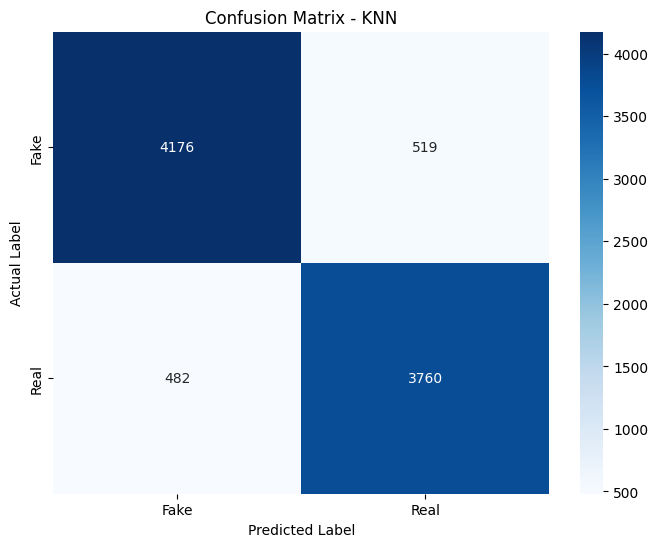

In [23]:
# ==========================================================
# STEP 11 — CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(
    y_test,
    y_pred_knn
)


# ==========================================================
# PLOT CONFUSION MATRIX
# ==========================================================

plt.figure(figsize=(8,6))

sns.heatmap(

    cm,

    annot=True,
    fmt='d',

    cmap='Blues',

    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)

plt.title("Confusion Matrix - KNN")

plt.xlabel("Predicted Label")

plt.ylabel("Actual Label")

plt.show()

# 📌 Interpretation of Confusion Matrix (KNN)

The confusion matrix helps us understand how well the K-Nearest Neighbors (KNN) model classified fake and real news articles.

The matrix is divided into four parts:

| Actual Class | Predicted Fake | Predicted Real |
|--------------|----------------|----------------|
| **Fake News** | 4176 | 519 |
| **Real News** | 482 | 3760 |

---

### 1. True Negative (TN) = 4176

These are **fake news articles correctly classified as fake**.

This indicates that the model successfully identified a large number of fake news samples.

---

### 2. False Positive (FP) = 519

These are **fake news articles incorrectly classified as real news**.

This is an important error because fake news escaping detection can reduce the reliability of the system.

A lower false positive value is preferred.

---

### 3. False Negative (FN) = 482

These are **real news articles incorrectly classified as fake news**.

This means some genuine news articles were wrongly flagged as fake.

Lower false negatives indicate better real-news detection.

---

### 4. True Positive (TP) = 3760

These are **real news articles correctly classified as real**.

This shows the model successfully identified a large portion of authentic news articles.

---

## Overall Observation

The confusion matrix shows that the KNN model correctly classified the majority of both fake and real news articles.

However, compared to Logistic Regression, KNN made a higher number of misclassifications, indicating comparatively weaker performance on TF-IDF text data.

This occurs because KNN relies on distance calculations, which become less effective in **high-dimensional sparse feature spaces** created by TF-IDF vectorization.

In [24]:
# ==========================================================
# STEP 12 — CLASSIFICATION REPORT
# ==========================================================

print("=" * 60)

print("CLASSIFICATION REPORT")

print("=" * 60)


print(

    classification_report(

        y_test,
        y_pred_knn,

        target_names=[

            "Fake News",
            "Real News"
        ]
    )
)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Fake News       0.90      0.89      0.89      4695
   Real News       0.88      0.89      0.88      4242

    accuracy                           0.89      8937
   macro avg       0.89      0.89      0.89      8937
weighted avg       0.89      0.89      0.89      8937



# 📌 Interpretation of Classification Report (KNN)

The classification report provides a detailed evaluation of the K-Nearest Neighbors (KNN) model using multiple performance metrics.

### 1. Precision
Precision measures:

> Out of all predictions made by the model for a class, how many were actually correct?

For **Fake News**, precision is **0.90**, meaning that when the model predicted an article as fake, it was correct **90% of the time**.

For **Real News**, precision is **0.88**, meaning that predictions for real news were correct **88% of the time**.

---

### 2. Recall
Recall measures:

> Out of all actual articles belonging to a class, how many were correctly identified?

For **Fake News**, recall is **0.89**, meaning the model correctly identified **89% of actual fake news articles**.

For **Real News**, recall is **0.89**, meaning the model correctly identified **89% of actual real news articles**.

---

### 3. F1-Score
F1-score is the harmonic mean of precision and recall.

It provides a balanced measure of model performance when both false positives and false negatives are important.

For:

- **Fake News → F1-score = 0.89**
- **Real News → F1-score = 0.88**

This indicates balanced classification performance across both classes.

---

### 4. Accuracy
The overall accuracy of the KNN model is:

## **88.80%**

This means the model correctly classified approximately **89 out of every 100 news articles**.

---

### 5. Overall Observation
Although KNN achieved good classification performance, it performed lower than Logistic Regression.

This is mainly because KNN relies on distance-based similarity, and TF-IDF creates a **high-dimensional sparse feature space**, making similarity calculations less effective.

Therefore, KNN showed comparatively lower performance and mild overfitting when compared to Logistic Regression.